In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad

from common import bsm_St,compare, bsm_put, halton_sequence, result, create_normal_sample

In [2]:
def lognormal_pdf(x: float, S0: float, r: float, sigma: float, T: float, t: float) -> float:
    mu=np.log(S0)+(r-sigma**2/2)*(T-t)
    sigma=sigma*np.sqrt(T-t)
    return (1 / (x * sigma * np.sqrt(2*np.pi))) * np.exp(- ((np.log(x) - mu)/sigma)**2 / 2)

def lognormal_cdf(x: float, S0: float, r: float, sigma: float, T: float, t: float) -> float:
    mu=np.log(S0)+(r-sigma**2/2)*(T-t)
    sigma=sigma*np.sqrt(T-t)
    return norm.cdf((np.log(x) - mu) / sigma)

def F(s: float, S: float, r: float, sigma: float, T: float, t: float) -> float:
    if s <= 0:
        return 0.0
    z = (np.log(s / S) - (r - 0.5 * sigma ** 2) * (T - t)) / (sigma * np.sqrt(T - t))
    return norm.cdf(z)

def sigma_f(t: float, S: float) -> float:  # on rend un exemple de volatilité locale
    return 0.25 + 0.1 * np.exp(-t) * S

In [3]:
S = 1
K = 0.9
r = 0.01
t = 0
T = 2
sigma = 0.25

N = 365 * T
m = 100000
dt = T / N

# 1.1 Distribution implicite

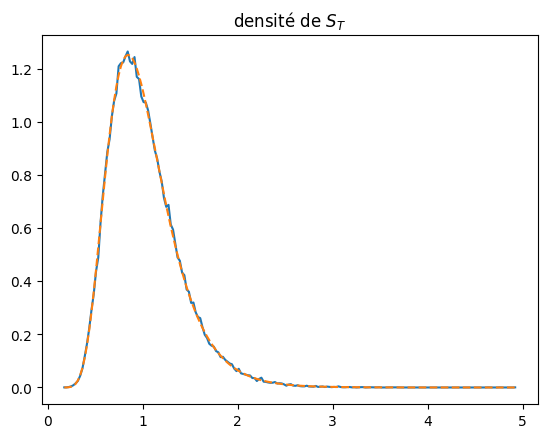

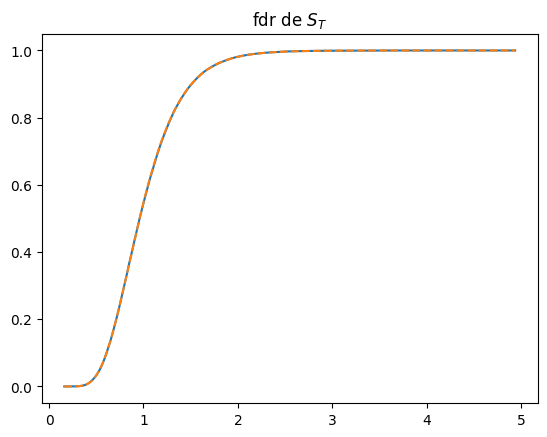

In [4]:
S_t=bsm_St(S,r,sigma,N,m,T,t)

empirical_y,edges=np.histogram(S_t.transpose()[-1],density=True,bins=200)
x = 0.5 * (edges[:-1] + edges[1:])
theorical_y = lognormal_pdf(x,S,r,sigma,T,t)
compare(x,empirical_y,theorical_y,global_title="densité de $S_T$")

empirical_y = np.arange(1, m + 1) / m
x = sorted(S_t.transpose()[-1])
theorical_y = lognormal_cdf(x, S, r, sigma, T, t)
compare(x, empirical_y, theorical_y,global_title="fdr de $S_T$")

# 1.2 Prix du put

1.2.1==============================
Put BSM:0.08125593038992285
1.2.2==============================
Prix du Put par intégration via F(s) : 0.08125593038992283
Erreur estimée de l'intégration : 1.858868456154203e-12
1.2.3==============================
Prix du Put par Monte Carlo (inversion CDF) : 0.08124965411763704
------------------------------
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 0.08124965411763718
std: 0.12530495842982883
erreur multiplicative: -7.724377359474843e-05
------------------------------


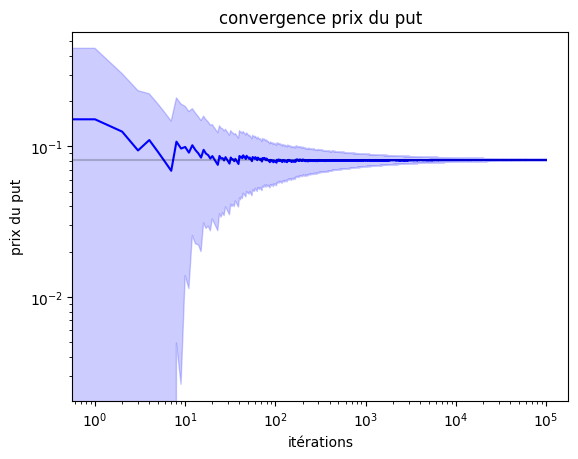

In [5]:
put=bsm_put(S, K, r, sigma,T)
print("1.2.1"+"=" * 30)
print(f"Put BSM:{put}")

integrand = lambda s: F(s,S, r, sigma, T, t)

# intégration sur [0, K]
price_num, error = quad(integrand, 0, K)
price_num = price_num * np.exp(-r * (T - t))
print("1.2.2"+"=" * 30)
print(f"Prix du Put par intégration via F(s) : {price_num}")
print(f"Erreur estimée de l'intégration : {error}")

mu = np.log(S) + (r - 0.5 * sigma ** 2) * (T - t)
sigma_T = sigma * np.sqrt(T - t)

U = halton_sequence((1,m)).transpose()
Z = norm.ppf(U)
ST = np.exp(mu + sigma_T * Z)

# payoff actualisé
payoffs = np.exp(-r * (T - t)) * np.maximum(K - ST, 0)
price_mc = np.mean(payoffs)

print("1.2.3"+"=" * 30)
print(f"Prix du Put par Monte Carlo (inversion CDF) : {price_mc}")
result([payoffs],put,y_title="prix du put",global_title="convergence prix du put")

# 1.3 Bonus : Fonction de répartition

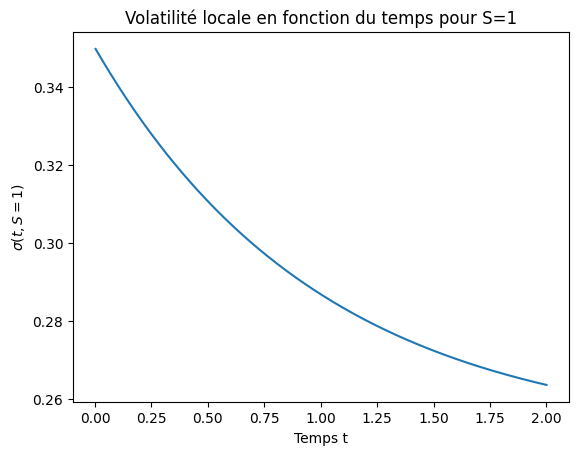

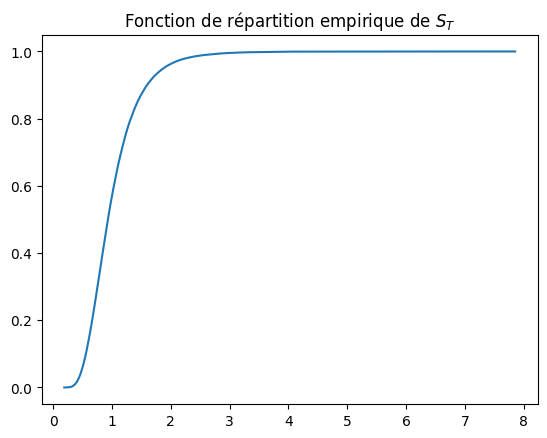

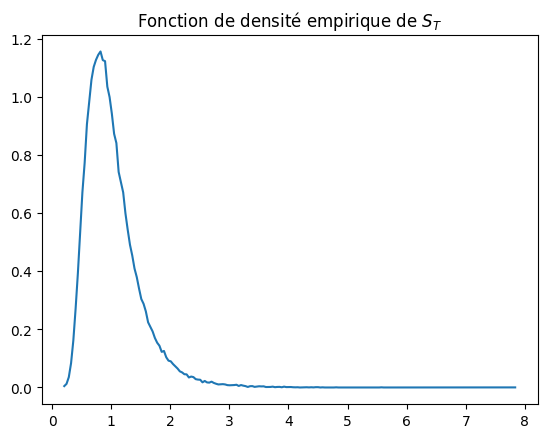

In [6]:
Si = np.full(m, S)
ti = np.arange(dt,T+dt,dt)
Z = create_normal_sample(m, N)
for i in range(N):
    vol = sigma_f(ti[i], Si)
    Si = Si * np.exp((r - 0.5 * vol ** 2) * dt + vol * np.sqrt(dt) * Z[:,i])  # Formule pour le schéma d'Euler

# estimation CDF
S_sorted = np.sort(Si)
cdf = np.arange(1, m + 1) / m

plt.plot(ti, sigma_f(ti, S=1.0))
plt.title("Volatilité locale en fonction du temps pour S=1")
plt.xlabel("Temps t")
plt.ylabel(r"$\sigma(t, S=1)$")
plt.show()

plt.plot(S_sorted,cdf)
plt.title("Fonction de répartition empirique de $S_T$")
plt.show()

empirical_y,edges=np.histogram(S_sorted,density=True,bins=200)
x = 0.5 * (edges[:-1] + edges[1:])
plt.plot(x,empirical_y)
plt.title("Fonction de densité empirique de $S_T$")
plt.show()